# Student Model — Knowledge Distillation + Curriculum Learning + QAT

1. **Curriculum Learning** — fases easy → easy+medium → full (dificultad creciente, dataset balanceado por fase)
2. **Knowledge Distillation** — soft targets del Teacher en cada fase
3. **QAT** — Quantization Aware Training
4. **TFLite INT8** — deploy en ESP32-CAM

> Requiere `teacher_final.keras` generado por `teacher.ipynb`

In [1]:
import os, sys
from pathlib import Path

# GPU: exponer libs CUDA del venv al linker dinámico
_nvidia = Path(sys.executable).parent.parent / 'lib' / 'python3.12' / 'site-packages' / 'nvidia'
_paths  = [str(p) for p in _nvidia.glob('*/lib') if p.is_dir()]
_paths.append('/usr/lib/wsl/lib')
os.environ['LD_LIBRARY_PATH'] = ':'.join(_paths + [os.environ.get('LD_LIBRARY_PATH', '')])
print('LD_LIBRARY_PATH configurado')


LD_LIBRARY_PATH configurado


## 1. Imports y configuración

In [2]:
import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

tf.random.set_seed(42)
import numpy as np; np.random.seed(42)

DATASET_DIR = Path('.')
CLASS_NAMES = ['Ausente', 'Izquierda', 'Centro', 'Derecha']
NUM_CLASSES = 4
IMG_SIZE    = 128
BATCH_SIZE  = 32
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

print(f'Keras {keras.__version__}')
print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')


I0000 00:00:1780363781.389926  414457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780363781.428754  414457 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780363782.350077  414457 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras 3.14.1
TensorFlow 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Carga, balance y separación del dataset

Mismo split que teacher. Cada dificultad se balancea por separado antes de armar las fases.

In [ ]:
def load_subset(difficulty: str, frac_start: float, frac_end: float) -> tuple:
    d = DATASET_DIR / difficulty
    entries = []
    with open(d / 'tags.txt') as f:
        for line in f:
            line = line.strip()
            if line:
                fname, label = line.split(',')
                entries.append((d / fname, int(label)))
    rng = np.random.default_rng(seed=SEED)
    entries = [entries[i] for i in rng.permutation(len(entries))]
    n = len(entries)
    entries = entries[int(frac_start * n) : int(frac_end * n)]
    X = np.array([
        np.array(Image.open(p).convert('L'), dtype=np.float32)[..., np.newaxis] / 255.0
        for p, _ in entries
    ])
    y = np.array([lbl for _, lbl in entries], dtype=np.int32)
    return X, y

def concat_splits(specs):
    parts = [load_subset(d, s, e) for d, s, e in specs]
    return np.concatenate([p[0] for p in parts]), np.concatenate([p[1] for p in parts])

def balance_dataset(X, y, target_per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    X_out, y_out = [], []
    for c in range(NUM_CLASSES):
        mask = y == c
        X_c = X[mask]
        idx = rng.choice(len(X_c), target_per_class, replace=(len(X_c) < target_per_class))
        X_out.append(X_c[idx])
        y_out.append(np.full(target_per_class, c, dtype=np.int32))
    X_out, y_out = np.concatenate(X_out), np.concatenate(y_out)
    return X_out[rng.permutation(len(X_out))], y_out[rng.permutation(len(X_out))]

# Mismo split que teacher
X_val, y_val = concat_splits([
    ('easy',   0.80, 0.90),
    ('medium', 0.80, 0.90),
    ('hard',   0.70, 0.85),
])
X_test, y_test = concat_splits([
    ('easy',   0.90, 1.00),
    ('medium', 0.90, 1.00),
    ('hard',   0.85, 1.00),
    ('other',  0.00, 1.00),
])

# Balance por dificultad
X_easy, y_easy = balance_dataset(*load_subset('easy',   0.00, 0.80), target_per_class=34)
X_med,  y_med  = balance_dataset(*load_subset('medium', 0.00, 0.80), target_per_class=38)
X_hard, y_hard = balance_dataset(*load_subset('hard',   0.00, 0.70), target_per_class=60)

# Fases cumulativas del Curriculum Learning
X_phase1, y_phase1 = X_easy, y_easy
X_phase2 = np.concatenate([X_easy, X_med]);         y_phase2 = np.concatenate([y_easy, y_med])
X_phase3 = np.concatenate([X_easy, X_med, X_hard]); y_phase3 = np.concatenate([y_easy, y_med, y_hard])

print(f'{"Split":<30} {"total":>5}  {"Aus":>4} {"Izq":>4} {"Cen":>4} {"Der":>4}  {"%aus":>5}')
print('-' * 60)
for name, y_p in [
    ('Fase 1 — easy',              y_phase1),
    ('Fase 2 — easy+medium',       y_phase2),
    ('Fase 3 — completo',          y_phase3),
    ('Val  (sin balance)',          y_val),
    ('Test (sin balance)',          y_test),
]:
    c = np.bincount(y_p, minlength=NUM_CLASSES)
    print(f'{name:<30} {len(y_p):>5}  {c[0]:>4} {c[1]:>4} {c[2]:>4} {c[3]:>4}  {c[0]/len(y_p)*100:>4.0f}%')


Split                          total   Aus  Izq  Cen  Der   %aus
------------------------------------------------------------
Fase 1 — easy                    136    34   34   34   34    25%
Fase 2 — easy+medium             288    72   72   72   72    25%
Fase 3 — completo                528   132  132  132  132    25%
Val  (sin balance)               119    55   17   31   16    46%
Test (sin balance)               204    93   33   60   18    46%


## 3. Pipeline tf.data

In [33]:
# Con datos balanceados los pesos son casi iguales, pero se mantienen como safety net
_counts   = np.bincount(y_phase3, minlength=NUM_CLASSES).astype(np.float32)
cw_tensor = tf.constant((len(y_phase3) / (NUM_CLASSES * _counts)).astype(np.float32))

@tf.function
def augment(x, y):
    crop = tf.random.uniform((), minval=int(0.82 * IMG_SIZE), maxval=IMG_SIZE, dtype=tf.int32)
    x = tf.image.random_crop(x, [crop, crop, 1])
    x = tf.image.resize(x, [IMG_SIZE, IMG_SIZE])
    x = tf.image.random_brightness(x, max_delta=0.15)
    x = tf.image.random_contrast(x, lower=0.75, upper=1.25)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

def make_ds(X, y, shuffle=False, aug=False, weighted=False):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y))
    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)
    if aug:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    if weighted:
        ds = ds.map(lambda x, y: (x, y, tf.gather(cw_tensor, y)),
                    num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

phase1_ds = make_ds(X_phase1, y_phase1, shuffle=True, aug=True, weighted=True)
phase2_ds = make_ds(X_phase2, y_phase2, shuffle=True, aug=True, weighted=True)
phase3_ds = make_ds(X_phase3, y_phase3, shuffle=True, aug=True, weighted=True)
val_ds    = make_ds(X_val,    y_val)
test_ds   = make_ds(X_test,   y_test)
print('Datasets listos')

Datasets listos


## 4. Arquitectura del Student

CNN liviana basada en CNN 3 del Lab 2. Target: ~7 KB cuantizado, >5 FPS en ESP32-CAM.

In [34]:
def build_student(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # Primer bloque: conv estándar (entrada de 1 canal, dw no aporta aquí)
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)          # → 64x64x32

    # Bloque 2: depthwise + pointwise
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, use_bias=False)(x)   # pointwise
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D()(x)          # → 32x32x64

    # Bloque 3: depthwise + pointwise (sin pooling, GAP reduce)
    x = layers.DepthwiseConv2D(3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, 1, use_bias=False)(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.ReLU()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='student')

student = build_student()
student.summary()
print(f'\nParámetros: {student.count_params():,}')
print(f'Tamaño float32: ~{student.count_params() * 4 / 1024:.1f} KB')
print(f'Tamaño INT8 estimado: ~{student.count_params() / 1024:.1f} KB')


Model: "student"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_6              │ (None, 64, 64, 32)     │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_7              │ (None, 32, 32, 64)     │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           26

 Total params: 8,580 (33.52 KB)

 Trainable params: 8,068 (31.52 KB)

 Non-trainable params: 512 (2.00 KB)


Parámetros: 8,580
Tamaño float32: ~33.5 KB
Tamaño INT8 estimado: ~8.4 KB


## 5. Carga del Teacher

In [35]:
teacher = keras.models.load_model('teacher_final.keras')
teacher.trainable = False
print('Teacher cargado')
_, acc_teacher = teacher.evaluate(test_ds, verbose=0)
print(f'Teacher accuracy en test: {acc_teacher * 100:.1f}%')


Teacher cargado
Teacher accuracy en test: 64.7%


## 6. Curriculum Learning — 6 fases cumulativas

Misma implementación que el teacher:
- `sparse_categorical_crossentropy` con labels enteras
- 180/clase por dificultad (misma escala de datos)
- 6 fases cumulativas idénticas
- `ModelCheckpoint` guarda el mejor modelo global

In [36]:
# ═════════════════════════════════════════════════════════
# Mismo training que el teacher: sparse_categorical_crossentropy
# con labels enteras y curriculum cumulativo de 6 fases.
# ═════════════════════════════════════════════════════════

TARGET = 190
X_easy_b, y_easy_b = balance_dataset(*load_subset('easy',   0.00, 0.80), target_per_class=TARGET)
X_med_b,  y_med_b  = balance_dataset(*load_subset('medium', 0.00, 0.80), target_per_class=TARGET)
X_hard_b, y_hard_b = balance_dataset(*load_subset('hard',   0.00, 0.70), target_per_class=TARGET)

n = TARGET * NUM_CLASSES  # 720

ph1_X, ph1_y = X_easy_b[:n//2],      y_easy_b[:n//2]
ph2_X, ph2_y = X_med_b[:int(n*.7)],  y_med_b[:int(n*.7)]
ph3_X, ph3_y = X_hard_b[:int(n*.3)], y_hard_b[:int(n*.3)]
ph4_X, ph4_y = X_easy_b[n//2:],      y_easy_b[n//2:]
ph5_X, ph5_y = X_med_b[int(n*.7):],  y_med_b[int(n*.7):]
ph6_X, ph6_y = X_hard_b[int(n*.3):], y_hard_b[int(n*.3):]

cum1_X, cum1_y = ph1_X, ph1_y
cum2_X = np.concatenate([cum1_X, ph2_X]); cum2_y = np.concatenate([cum1_y, ph2_y])
cum3_X = np.concatenate([cum2_X, ph3_X]); cum3_y = np.concatenate([cum2_y, ph3_y])
cum4_X = np.concatenate([cum3_X, ph4_X]); cum4_y = np.concatenate([cum3_y, ph4_y])
cum5_X = np.concatenate([cum4_X, ph5_X]); cum5_y = np.concatenate([cum4_y, ph5_y])
cum6_X = np.concatenate([cum5_X, ph6_X]); cum6_y = np.concatenate([cum5_y, ph6_y])

print('Fases cumulativas:')
for i, (X_p, y_p) in enumerate([(cum1_X,cum1_y),(cum2_X,cum2_y),(cum3_X,cum3_y),
                                   (cum4_X,cum4_y),(cum5_X,cum5_y),(cum6_X,cum6_y)], 1):
    n_b = len(X_p) // BATCH_SIZE
    print(f'  F{i}: {len(X_p):>5} imgs  ({n_b} batches/epoch)')

# Compilar igual que el teacher
student.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print('\nStudent compilado  (sparse_categorical_crossentropy)')


Fases cumulativas:
  F1:   380 imgs  (11 batches/epoch)
  F2:   912 imgs  (28 batches/epoch)
  F3:  1140 imgs  (35 batches/epoch)
  F4:  1520 imgs  (47 batches/epoch)
  F5:  1748 imgs  (54 batches/epoch)
  F6:  2280 imgs  (71 batches/epoch)

Student compilado  (sparse_categorical_crossentropy)


### Entrenamiento — 6 fases cumulativas (igual que teacher)

In [37]:
rlr  = keras.callbacks.ReduceLROnPlateau(
    factor=0.8, patience=8, min_lr=1e-6, monitor='val_loss', verbose=1)
ckpt = keras.callbacks.ModelCheckpoint(
    'student_best.weights.h5', save_best_only=True,
    monitor='val_loss', mode='min', verbose=1, save_weights_only=True)

# LR se resetea a 5e-3 en cada fase: el modelo necesita capacidad de adaptación
# al agregar datos más difíciles (no menos LR cuando más necesita aprender)
LR_PHASE = 7e-4
EPH = 80

phases_data = [
    (cum1_X, cum1_y, 'F1: easy[0-50%]'),
    (cum2_X, cum2_y, 'F2: +medium[0-70%]'),
    (cum3_X, cum3_y, 'F3: +hard[0-30%]'),
    (cum4_X, cum4_y, 'F4: +easy[50-100%]'),
    (cum5_X, cum5_y, 'F5: +medium[70-100%]'),
    (cum6_X, cum6_y, 'F6: +hard[30-100%]'),
]

histories = []
student.optimizer.learning_rate.assign(LR_PHASE)
for X_p, y_p, name in phases_data:
    # Reset LR al inicio de cada fase
    # student.optimizer.learning_rate.assign(LR_PHASE)
    print(f'\n=== {name} ({len(X_p)} imgs, {len(X_p)//BATCH_SIZE} bat/ep, LR reset={LR_PHASE}) ===')
    h = student.fit(
        make_ds(X_p, y_p, shuffle=True, aug=True),
        epochs=EPH, validation_data=val_ds,
        callbacks=[rlr, ckpt],
    )
    histories.append(h)
    acc_val = float(np.mean(np.argmax(student.predict(X_val, verbose=0), axis=1) == y_val))
    print(f'  Val accuracy al terminar {name}: {acc_val*100:.1f}%')



=== F1: easy[0-50%] (380 imgs, 11 bat/ep, LR reset=0.0007) ===
Epoch 1/80


I0000 00:00:1780365270.798982  414546 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_439016__.60


 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1849 - loss: 1.5154

I0000 00:00:1780365272.928369  414548 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_439016__.60


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.2013 - loss: 1.5057
Epoch 1: val_loss improved from None to 1.38325, saving model to student_best.weights.h5

Epoch 1: finished saving model to student_best.weights.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.2395 - loss: 1.4798 - val_accuracy: 0.1345 - val_loss: 1.3833 - learning_rate: 7.0000e-04
Epoch 2/80
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2305 - loss: 1.4584
Epoch 2: val_loss did not improve from 1.38325
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2579 - loss: 1.4525 - val_accuracy: 0.1345 - val_loss: 1.4171 - learning_rate: 7.0000e-04
Epoch 3/80
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2723 - loss: 1.4040
Epoch 3: val_loss did not improve from 1.38325
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2579 - loss: 1.4305 - val_accuracy: 0.1345 - val_loss: 1.4518 - learning_rate: 7.0000e-04
Epoch 4/80
10/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2267 - loss: 1.

...

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.2487 - loss: 1.4183
Epoch 1: val_loss did not improve from 1.38325
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.2675 - loss: 1.4077 - val_accuracy: 0.1849 - val_loss: 1.4078 - learning_rate: 9.3952e-05
Epoch 2/80
26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2743 - loss: 1.3931
Epoch 2: val_loss did not improve from 1.38325
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2643 - loss: 1.3959 - val_accuracy: 0.1849 - val_loss: 1.4035 - learning_rate: 9.3952e-05
Epoch 3/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2571 - loss: 1.4078
Epoch 3: val_loss did not improve from 1.38325
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2522 - loss: 1.4072 - val_accuracy: 0.1849 - val_loss: 1.3975 - learning_rate: 9.3952e-05
Epoch 4/80
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2445 - loss: 1.3976
Epoch 4: val_loss did not improve from 1.38325
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy:

I0000 00:00:1780365339.092431  414548 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_439016__.60


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2619 - loss: 1.3998
Epoch 1: val_loss did not improve from 1.38325
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.2798 - loss: 1.3949 - val_accuracy: 0.1429 - val_loss: 1.4104 - learning_rate: 1.0088e-05
Epoch 2/80
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.2887 - loss: 1.3910
Epoch 2: val_loss did not improve from 1.38325
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2711 - loss: 1.3957 - val_accuracy: 0.1513 - val_loss: 1.4089 - learning_rate: 1.0088e-05
Epoch 3/80
33/36 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2824 - loss: 1.3841
Epoch 3: val_loss did not improve from 1.38325
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2754 - loss: 1.3905 - val_accuracy: 0.1429 - val_loss: 1.4092 - learning_rate: 1.0088e-05
Epoch 4/80
33/36 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2610 - loss: 1.3948
Epoch 4: val_loss did not improve from 1.38325
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy:

I0000 00:00:1780365528.167937  414549 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_439016__.60


72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2705 - loss: 1.3937
Epoch 1: val_loss did not improve from 1.38325
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.2706 - loss: 1.3942 - val_accuracy: 0.1345 - val_loss: 1.4037 - learning_rate: 1.0000e-06
Epoch 2/80
71/72 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2530 - loss: 1.3929
Epoch 2: val_loss did not improve from 1.38325
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2513 - loss: 1.3942 - val_accuracy: 0.1345 - val_loss: 1.4029 - learning_rate: 1.0000e-06
Epoch 3/80
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2402 - loss: 1.4065
Epoch 3: val_loss did not improve from 1.38325
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2478 - loss: 1.4054 - val_accuracy: 0.1429 - val_loss: 1.4007 - learning_rate: 1.0000e-06
Epoch 4/80
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2665 - loss: 1.3943
Epoch 4: val_loss did not improve from 1.38325
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy:

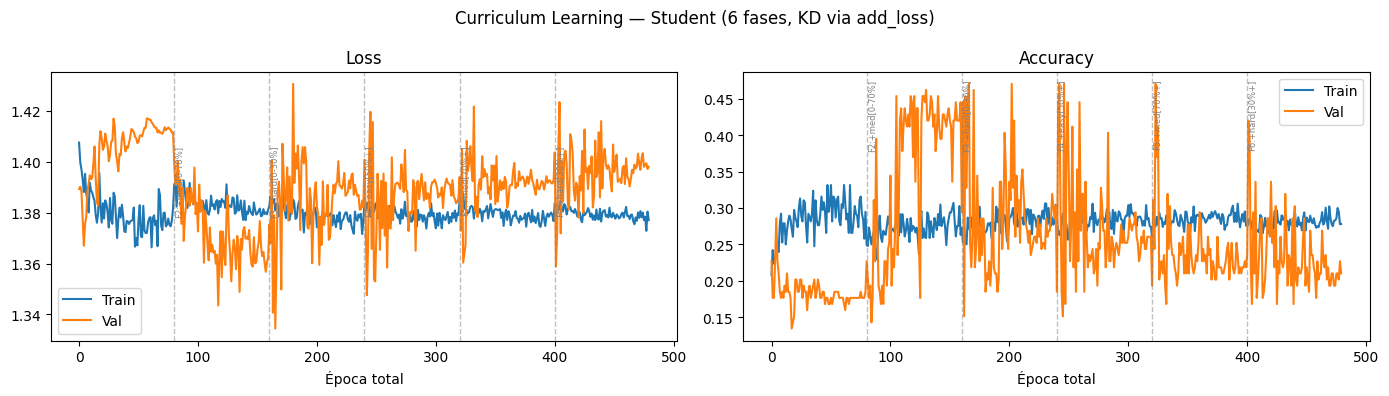

In [19]:
def cat(key, hists):
    return [v for h in hists for v in h.history[key]]

phase_labels = ['F1:easy[0-50%]', 'F2:+med[0-70%]', 'F3:+hard[0-30%]',
                'F4:+easy[50%+]',  'F5:+med[70%+]',  'F6:+hard[30%+]']
boundaries   = list(np.cumsum([len(h.history['loss']) for h in histories[:-1]]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
for ax, key, title in [(ax1, 'loss', 'Loss'), (ax2, 'accuracy', 'Accuracy')]:
    ax.plot(cat(key, histories),          label='Train')
    ax.plot(cat(f'val_{key}', histories), label='Val')
    for b, label in zip(boundaries, phase_labels[1:]):
        ax.axvline(b, color='gray', linestyle='--', alpha=0.5, linewidth=1)
        ax.text(b + 0.3, ax.get_ylim()[1] * 0.98, label,
                fontsize=6, rotation=90, va='top', color='gray')
    ax.set_title(title); ax.set_xlabel('Época total'); ax.legend()
plt.suptitle('Curriculum Learning — Student (6 fases, KD via add_loss)')
plt.tight_layout(); plt.show()


## 7. Post-Training Quantization (PTQ)

Cuantización post-entrenamiento integrada en el TFLite converter. No requiere tfmot y da resultados similares a QAT para modelos pequeños (<10 KB).

In [20]:
# Cargar mejor checkpoint
student.load_weights('student_best.weights.h5')
trained_student = student

y_pred_kd = np.argmax(student.predict(X_test, verbose=0), axis=1)
acc_kd = float(np.mean(y_pred_kd == y_test))
print(f'Student (float32) accuracy en test: {acc_kd * 100:.1f}%')


Student (float32) accuracy en test: 30.4%


## 7. Conversión a TFLite INT8 (PTQ)

Post-Training Quantization integrada en el converter. El representative dataset calibra los rangos de activación.

In [21]:
# Post-Training Quantization (PTQ) — sin tfmot
def representative_dataset_gen():
    for i in range(0, min(200, len(X_phase3)), BATCH_SIZE):
        yield [X_phase3[i : i + BATCH_SIZE].astype('float32')]

converter = tf.lite.TFLiteConverter.from_keras_model(trained_student)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()
Path('student_int8.tflite').write_bytes(tflite_model)
print(f'TFLite guardado: {len(tflite_model)/1024:.1f} KB')


INFO:tensorflow:Assets written to: /tmp/tmp679dq8yu/assets


INFO:tensorflow:Assets written to: /tmp/tmp679dq8yu/assets


Saved artifact at '/tmp/tmp679dq8yu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  126055277969872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277971792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277971408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277971024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277970064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277969488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277972368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277972560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277971600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126055277972176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12605527797121

/home/raisrb/uandes/sistemas-embebidos/Rep_SE_202601_grupo_Rodriguez_Guzman_Molfino/Lab_3/Extra_1/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1780364852.190499  414457 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780364852.190539  414457 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780364852.190657  414457 reader.cc:83] Reading SavedModel from: /tmp/tmp679dq8yu
I0000 00:00:1780364852.191296  414457 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780364852.191302  414457 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp679dq8yu
I0000 00:00:1780364852.197955  414457 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1780364852.239898  414457 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp679dq8yu
I

TFLite guardado: 21.0 KB


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1780364854.439161  414457 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [22]:
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_det  = interpreter.get_input_details()[0]
output_det = interpreter.get_output_details()[0]
scale, zero_point = input_det['quantization']

y_tflite = []
for img in X_test:
    img_q = (img / scale + zero_point).astype(np.int8)
    interpreter.set_tensor(input_det['index'], img_q[np.newaxis])
    interpreter.invoke()
    y_tflite.append(np.argmax(interpreter.get_tensor(output_det['index'])))
y_tflite = np.array(y_tflite)

acc_tflite = np.mean(y_tflite == y_test)
print(f'Student TFLite INT8 accuracy en test: {acc_tflite * 100:.1f}%')

Student TFLite INT8 accuracy en test: 30.4%


/home/raisrb/uandes/sistemas-embebidos/Rep_SE_202601_grupo_Rodriguez_Guzman_Molfino/Lab_3/Extra_1/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## 9. Benchmarking

In [23]:
_, acc_teacher_test = teacher.evaluate(test_ds, verbose=0)

rows = [
    ('Teacher (float32)',  acc_teacher_test, teacher.count_params() * 4),
    ('Student (float32)', acc_kd,            trained_student.count_params() * 4),
    ('Student TFLite INT8', acc_tflite,      len(tflite_model)),
]
print('{:<28} {:>10} {:>12}'.format('Modelo', 'Accuracy', 'Tamaño'))
print('-' * 53)
for name, acc, size_b in rows:
    print('{:<28} {:>9.1f}%  {:>8.1f} KB'.format(name, acc * 100, size_b / 1024))


Modelo                         Accuracy       Tamaño
-----------------------------------------------------
Teacher (float32)                 64.7%    6195.8 KB
Student (float32)                 30.4%      33.5 KB
Student TFLite INT8               30.4%      21.0 KB


### 9.2 Matriz de confusión — Student TFLite INT8

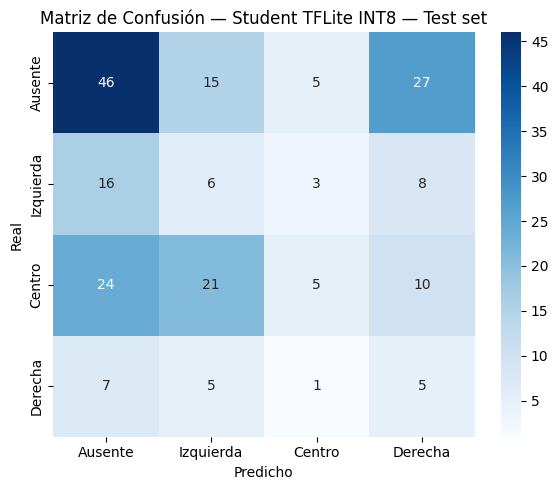

              precision    recall  f1-score   support

     Ausente       0.49      0.49      0.49        93
   Izquierda       0.13      0.18      0.15        33
      Centro       0.36      0.08      0.14        60
     Derecha       0.10      0.28      0.15        18

    accuracy                           0.30       204
   macro avg       0.27      0.26      0.23       204
weighted avg       0.36      0.30      0.30       204



In [24]:
cm = confusion_matrix(y_test, y_tflite)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Student TFLite INT8 — Test set')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_tflite, target_names=CLASS_NAMES))

### 9.3 Ejemplos con entradas y salidas

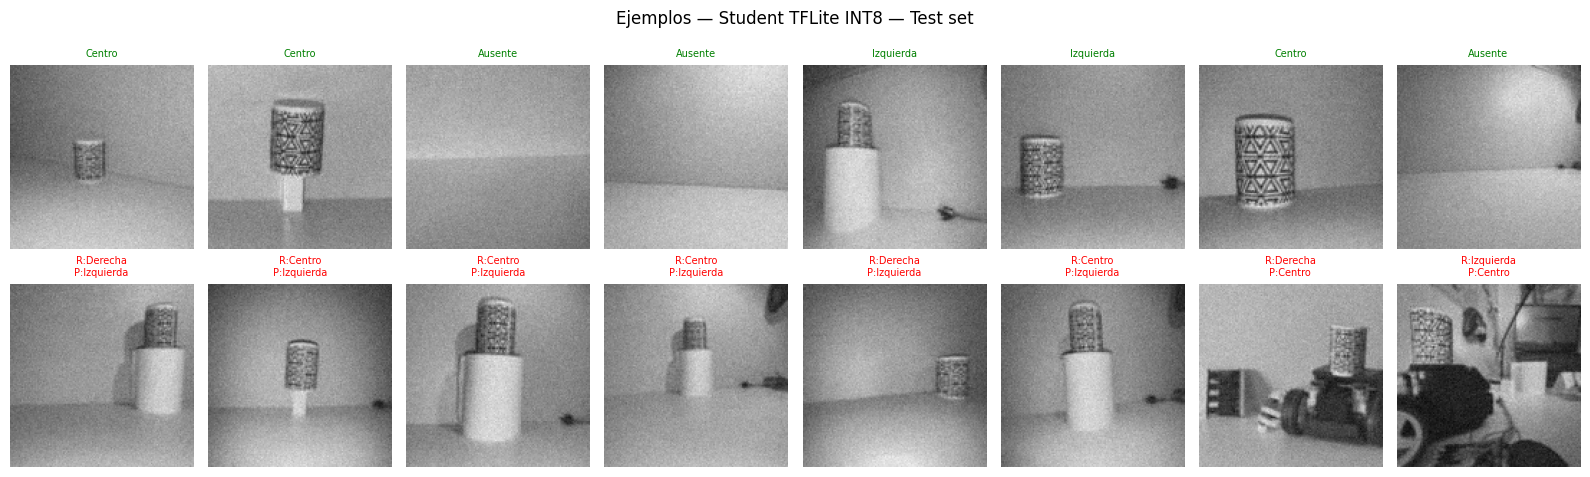

In [20]:
n_show = 8
correct_idx   = np.where(y_tflite == y_test)[0]
incorrect_idx = np.where(y_tflite != y_test)[0]

fig, axes = plt.subplots(2, n_show, figsize=(16, 5))
for row, (idxs, row_label, color) in enumerate([
    (correct_idx,   'Correctas',   'green'),
    (incorrect_idx, 'Incorrectas', 'red'),
]):
    for col in range(n_show):
        ax = axes[row, col]
        if col < len(idxs):
            idx = idxs[col]
            ax.imshow(X_test[idx, :, :, 0], cmap='gray', vmin=0, vmax=1)
            real = CLASS_NAMES[y_test[idx]]
            pred = CLASS_NAMES[y_tflite[idx]]
            title = real if row == 0 else f'R:{real}\nP:{pred}'
            ax.set_title(title, fontsize=7, color=color)
        ax.axis('off')
    axes[row, 0].set_ylabel(row_label, fontsize=9)
plt.suptitle('Ejemplos — Student TFLite INT8 — Test set')
plt.tight_layout(); plt.show()

## 10. Guardar modelos

In [ ]:
trained_student.save('student_kd.keras')
print('Guardados:')
print('  student_kd.keras     — Student (float32)')
print('  student_int8.tflite  — Listo para ESP32-CAM')
print(f'  Params: {trained_student.count_params():,}')
